# 1 Introduction

- RAG is a technique to augment the knowledge of LLM.
- The knowldege of LLM Is restricted the cutt off date or to the data on which it was trained .
- Rag is a technique to augment LLM knowledge

- Rag
    * Indexing 
    * Retreival and augmenting

# 2 .  Indexing

- Document load
- Split  -  to reduce the data and also fit for model context window
- Store in vector store

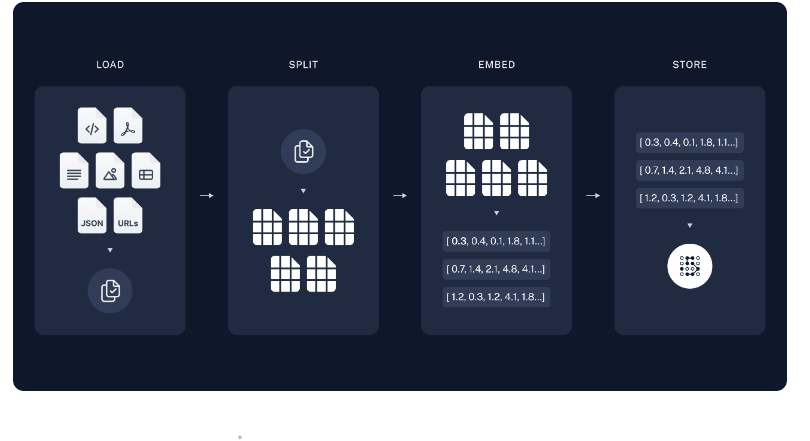


# 3. Retreival and generation
- Retrieve: Given a user input, relevant splits are retrieved from storage using a Retriever.
- 
Generate: A ChatModel / LLM produces an answer using a prompt that includes the question and the retrieved data

# Installation

In [7]:
# !pip install langchain langchain_community langchain_chroma
# !pip install -qU langchain-openai

### Document loading

In [24]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

# Only keep post title, headers, and content from the full HTML.
bs4_strainer = bs4.SoupStrainer(class_=("post-title", "post-header", "post-content"))
loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs={"parse_only": bs4_strainer},
)
docs = loader.load()

len(docs[0].page_content)

43047

In [25]:
print(docs[0].page_content[:500])



      LLM Powered Autonomous Agents
    
Date: June 23, 2023  |  Estimated Reading Time: 31 min  |  Author: Lilian Weng


Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.
Agent System Overview#
In


### Split

- Splitting is nessacary because of the context window of model or if the context window matches the model it is hard to find the information from relevant document

In [26]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200, add_start_index=True
)
all_splits = text_splitter.split_documents(docs)

len(all_splits)

63

### Store

In [28]:
# !pip install langchain-huggingface==0.2.0


In [14]:
from langchain_huggingface import HuggingFaceEmbeddings

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-mpnet-base-v2")
from langchain_chroma import Chroma

vector_store = Chroma(embedding_function=embeddings,
                     persist_directory='v1')
ids = vector_store.add_documents(documents=all_splits)

### Retreiver

In [15]:
retreiver = vector_store.as_retriever(search_type = 'similarity' ,k=4)
retreived_doc = retreiver.invoke('"What are the approaches to Task Decomposition?')
retreived_doc

[Document(id='f2b3dc57-a9fd-4937-8945-43600e7f849a', metadata={'start_index': 2578, 'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Task decomposition can be done (1) by LLM with simple prompting like "Steps for XYZ.\\n1.", "What are the subgoals for achieving XYZ?", (2) by using task-specific instructions; e.g. "Write a story outline." for writing a novel, or (3) with human inputs.\nAnother quite distinct approach, LLM+P (Liu et al. 2023), involves relying on an external classical planner to do long-horizon planning. This approach utilizes the Planning Domain Definition Language (PDDL) as an intermediate interface to describe the planning problem. In this process, LLM (1) translates the problem into “Problem PDDL”, then (2) requests a classical planner to generate a PDDL plan based on an existing “Domain PDDL”, and finally (3) translates the PDDL plan back into natural language. Essentially, the planning step is outsourced to an external tool, assuming

In [21]:
len(retreived_doc)

4

### Generate 

In [17]:
import os

In [18]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="https://api.together.xyz/v1",
    api_key=os.environ["TOGETHERAI_API_KEY"],
    model="mistralai/Mixtral-8x7B-Instruct-v0.1",
)

The function `create_stuff_documents_chain` from **LangChain** is used to create a chain that combines multiple documents into a single input for a language model. This method concatenates or "stuffs" all documents together and then passes them to the language model for processing.

It’s useful when you need to handle multiple documents and want to generate a combined output.

The function `create_retrieval_chain` from **LangChain** is used to create a retrieval-based question-answering chain. 
**It combines a language model with a retrieval component to search through a knowledge base or documents and return relevant results.**

This chain helps answer questions by fetching context from external sources, like databases or document stores.`

In [19]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate

system_prompt = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer "
    "the question. If you don't know the answer, say that you "
    "don't know. Use three sentences maximum and keep the "
    "answer concise."
    "\n\n"
    "{context}"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("human", "{input}"),
    ]
)


question_answer_chain = create_stuff_documents_chain(llm, prompt)
rag_chain = create_retrieval_chain(retreiver, question_answer_chain)

response = rag_chain.invoke({"input": "What is Task Decomposition?"})
print(response["answer"])

 Task decomposition is the process of breaking down a complex task into smaller, manageable sub-tasks. In the context of AI, this can be achieved through various methods such as prompting a large language model (LLM) with simple instructions, providing task-specific inputs, or using an external classical planner for long-horizon planning. The Planning Domain Definition Language (PDDL) is often used as an interface to describe the planning problem in this approach. Another method is Chain of Thought (CoT), where the model is instructed to think step by step, decomposing the task into simpler sub-tasks. This process helps shed light on the model's thinking and generates a clear interpretation of the problem-solving process.


# Conversational RAG

- THIS DEASLS WITH HAVING A CONVERSATION WITH THE MODEL BY HAVING SOME HISTORY.
- need to incorporate past q&a into current input

Human: "What is Task Decomposition?"

AI: "Task decomposition involves breaking down complex tasks into smaller and simpler steps to make them more manageable for an agent or model."

Human: "What are common ways of doing it?"

- updation of prompt using conversational history
- contexulaise rephrasing of the input.
* query -> retriever
* Now we will have:
 (query, conversation history) -> LLM -> rephrased query -> retrieve


First we'll need to define a sub-chain that takes historical messages and the latest user question, and reformulates the question if it makes reference to any information in the historical information.

We'll use a prompt that includes a MessagesPlaceholder variable under the name "chat_history". This allows us to pass in a list of Messages to the prompt using the "chat_history" input key, and these messages will be inserted after the system message and before the human message containing the latest question.

The `MessagesPlaceholder` from **`langchain_core.prompts`** is used as a placeholder for messages in a prompt template. It allows for dynamic insertion of multiple messages, typically when building conversation chains. 

This is particularly useful when the system needs to accumulate messages over time in chat-like applications. The placeholder is replaced with actual messages during runtime execution of the chain.

In [21]:
from langchain.chains import create_history_aware_retriever
from langchain_core.prompts import MessagesPlaceholder

contextualize_q_system_prompt = (
    "Given a chat history and the latest user question "
    "which might reference context in the chat history, "
    "formulate a standalone question which can be understood "
    "without the chat history. Do NOT answer the question, "
    "just reformulate it if needed and otherwise return it as is."
)

contextualize_q_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", contextualize_q_system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}"),
    ]
)
history_aware_retriever = create_history_aware_retriever(
    llm, retreiver, contextualize_q_prompt
)

In [22]:
from langchain.chains import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain

qa_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder("chat_history"),
        ("human", "{input}"),
    ]
)


question_answer_chain = create_stuff_documents_chain(llm, qa_prompt)

rag_chain = create_retrieval_chain(history_aware_retriever, question_answer_chain)

In [23]:
from langchain_core.messages import AIMessage, HumanMessage

chat_history = []

question = "What is Task Decomposition?"
ai_msg_1 = rag_chain.invoke({"input": question, "chat_history": chat_history})
chat_history.extend(
    [
        HumanMessage(content=question),
        AIMessage(content=ai_msg_1["answer"]),
    ]
)

second_question = "What are common ways of doing it?"
ai_msg_2 = rag_chain.invoke({"input": second_question, "chat_history": chat_history})

print(ai_msg_2["answer"])

 Common ways of doing task decomposition include:

1. Using simple prompting with a language model, such as asking "Steps for XYZ" or "What are the subgoals for achieving XYZ?"
2. Providing task-specific instructions, like "Write a story outline" for writing a novel.
3. Utilizing human inputs to break down complex tasks into simpler steps.
4. Employing the LLM+P approach, which involves using an external classical planner to do long-horizon planning with the help of the Planning Domain Definition Language (PDDL).
5. Implementing techniques like Chain of Thought (CoT) and Tree of Thoughts (ToT), which decompose problems into multiple manageable tasks and explore various reasoning possibilities.


### Statefull managment of chat history

Here we've gone over how to add application logic for incorporating historical outputs, but we're still manually updating the chat history and inserting it into each input. In a real Q&A application we'll want some way of persisting chat history and some way of automatically inserting and updating it.

In [43]:
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_core.chat_history import BaseChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

store = {}


def get_session_history(session_id: str) -> BaseChatMessageHistory:
    if session_id not in store:
        store[session_id] = ChatMessageHistory()
    return store[session_id]


conversational_rag_chain = RunnableWithMessageHistory(
    rag_chain,
    get_session_history,
    input_messages_key="input",
    history_messages_key="chat_history",
    output_messages_key="answer",
)

In [46]:
conversational_rag_chain.invoke(
    {"input": "What is Task Decomposition?"},
    config={
        "configurable": {"session_id": "abc123"}
    },  # constructs a key "abc123" in `store`.
)["answer"]

" Task decomposition is a process in complex task handling where a large task is broken down into smaller, manageable steps. This can be done using a Language Learning Model (LLM) with simple prompting, task-specific instructions, or human inputs. It's often used in AI systems to make complex tasks more manageable and to provide insight into the thinking process of the model."

In [47]:
conversational_rag_chain.invoke(
    {"input": "What are common ways of doing it?"},
    config={"configurable": {"session_id": "abc123"}},
)["answer"]

' Common ways of doing task decomposition include using a Language Learning Model (LLM) with simple prompting, such as asking "Steps for XYZ.\\n1." or "What are the subgoals for achieving XYZ?" Another way is using task-specific instructions, like "Write a story outline." for writing a novel, or any other specific instructions relevant to the task at hand. Lastly, human inputs can also be used for task decomposition, especially when the task requires specific human expertise or knowledge.'

In [48]:
conversational_rag_chain.invoke(
    {"input": "What is the best way of doing it?"},
    config={"configurable": {"session_id": "abc123"}},
)["answer"]

' The "best" way of doing task decomposition can depend on the specific task and the resources available. However, the Tree of Thoughts approach, as described in the context, seems to be a comprehensive method as it explores multiple reasoning possibilities at each step, creating a tree structure. This method can provide a more thorough and nuanced breakdown of complex tasks. It also allows for different search methods, such as breadth-first search (BFS) or depth-first search (DFS), and uses a classifier or majority vote for evaluating each state. This approach can be beneficial for tasks that require a deep understanding and exploration of multiple aspects. Nevertheless, it\'s essential to consider the specific requirements and constraints of each task when deciding on the best way to decompose it.'

In [49]:
for message in store["abc123"].messages:
    if isinstance(message, AIMessage):
        prefix = "AI"
    else:
        prefix = "User"

    print(f"{prefix}: {message.content}\n")

User: What is Task Decomposition?

AI:  Task decomposition is a process in complex task handling where a large task is broken down into smaller, manageable steps. This can be done using a Language Learning Model (LLM) with simple prompting, task-specific instructions, or human inputs. It's often used in AI systems to make complex tasks more manageable and to provide insight into the thinking process of the model.

User: What are common ways of doing it?

AI:  Common ways of doing task decomposition include using a Language Learning Model (LLM) with simple prompting, such as asking "Steps for XYZ.\n1." or "What are the subgoals for achieving XYZ?" Another way is using task-specific instructions, like "Write a story outline." for writing a novel, or any other specific instructions relevant to the task at hand. Lastly, human inputs can also be used for task decomposition, especially when the task requires specific human expertise or knowledge.

User: What is the best way of doing it?

AI:

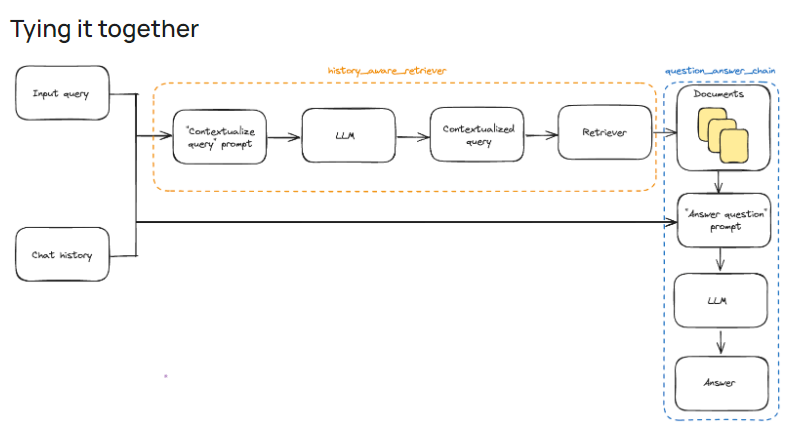